This notebook studies our dataset exclusively for the range DURING the streetlight modernization project. The data are from 2025-06-21 to 2026-03-21

In [1]:
from allsky.plotting import plot_exposure, plot_brightness, plot_synthetic_luminous_flux
from pathlib import Path
import pandas as pd


image_location = Path("../../images/SelectedSkyImages/")
clear_image_location = Path("../../images/FinalSkyImages/")
enriched_df_location = Path("../../data/enriched_df.parquet")

if (not image_location.exists()) or (not enriched_df_location.exists()):
    raise FileNotFoundError

enriched_df = pd.read_parquet(enriched_df_location)

Remove rows for images that were in `SelectedSkyImages` but not in `FinalSkyImages`

In [2]:
enriched_df

,date,time,exposure,filename,source_file,timestamp,image_paths,image_mean,image_sum,image_min,image_max,image_std,image_medians
8,2010/08/11,22:38:00,2.7883,000021274,2010-08.parquet,2010-08-11 22:38:00,../../images/SomeSkyImages/2010-08/AllSkyImage...,157.789822,19822662,105,242,29.416727,156.0
9,2010/08/11,22:39:17,2.4769,000021275,2010-08.parquet,2010-08-11 22:39:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,159.858382,20082529,102,242,25.961395,158.0
10,2010/08/11,22:40:17,2.4769,000021276,2010-08.parquet,2010-08-11 22:40:17,../../images/SomeSkyImages/2010-08/AllSkyImage...,163.385713,20525657,115,240,25.684782,161.0
11,2010/08/11,22:41:34,2.4769,000021277,2010-08.parquet,2010-08-11 22:41:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,166.985608,20977901,117,245,28.818942,163.0
12,2010/08/11,22:42:34,2.4769,000021278,2010-08.parquet,2010-08-11 22:42:34,../../images/SomeSkyImages/2010-08/AllSkyImage...,158.146314,19867447,99,248,34.864647,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026/03/25,05:40:08,32.0241,000422467,2026-03.parquet,2026-03-25 05:40:08,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.790141,13038844,51,221,19.991641,102.0
5,2026/03/25,05:40:41,32.0241,000422468,2026-03.parquet,2026-03-25 05:40:41,../../images/SomeSkyImages/2026-03/AllSkyImage...,103.978412,13062496,57,235,19.158357,102.0
6,2026/03/25,05:41:34,36.3559,000422469,2026-03.parquet,2026-03-25 05:41:34,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.699698,13529990,56,232,20.021279,105.0
7,2026/03/25,05:42:11,36.3559,000422470,2026-03.parquet,2026-03-25 05:42:11,../../images/SomeSkyImages/2026-03/AllSkyImage...,107.371680,13488782,59,253,21.015155,105.0


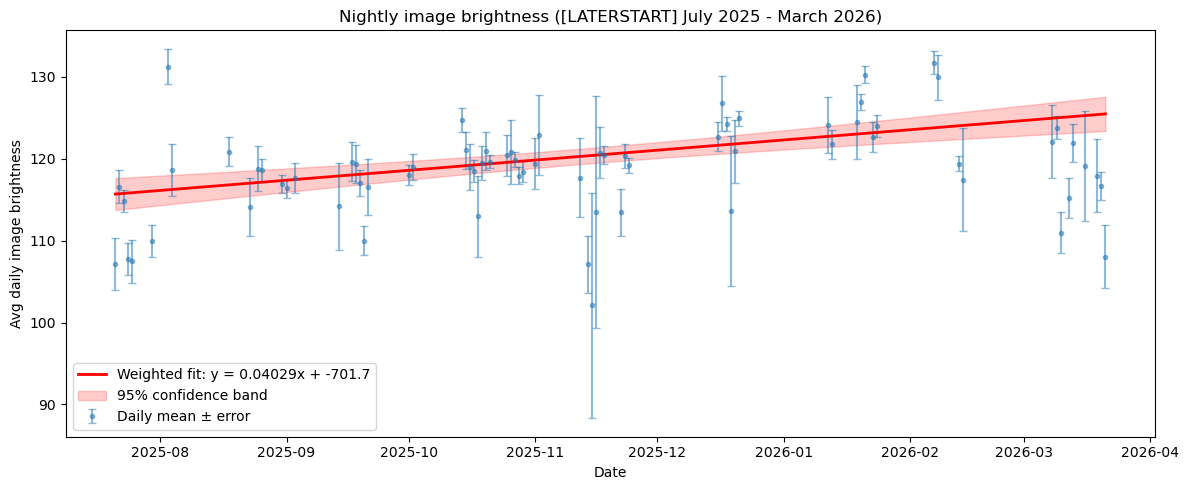

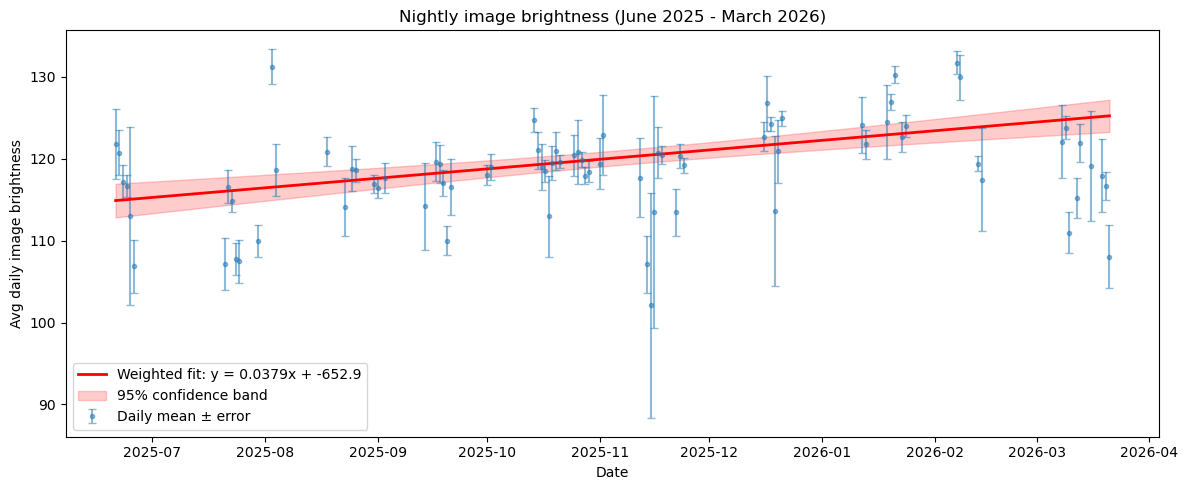

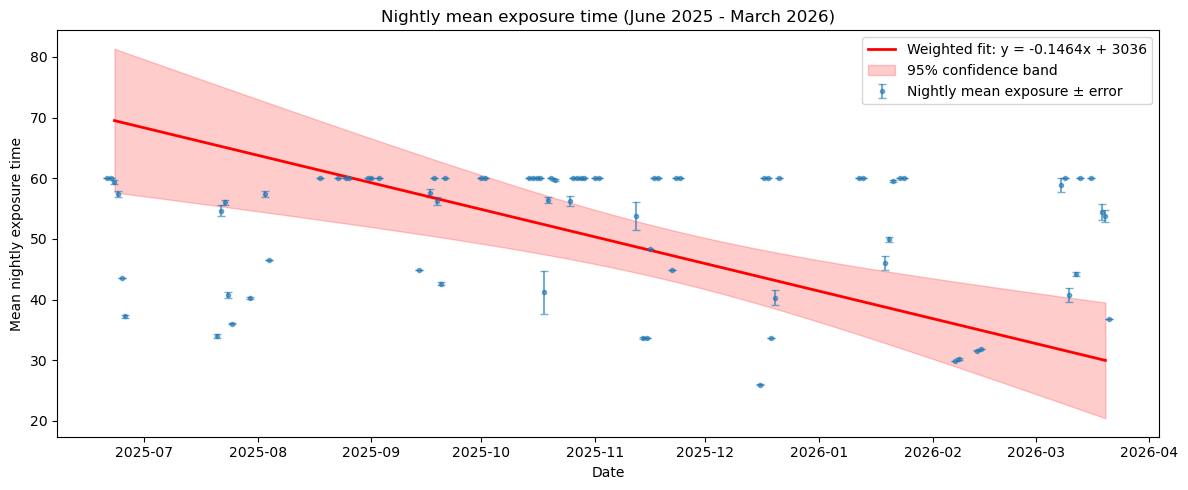

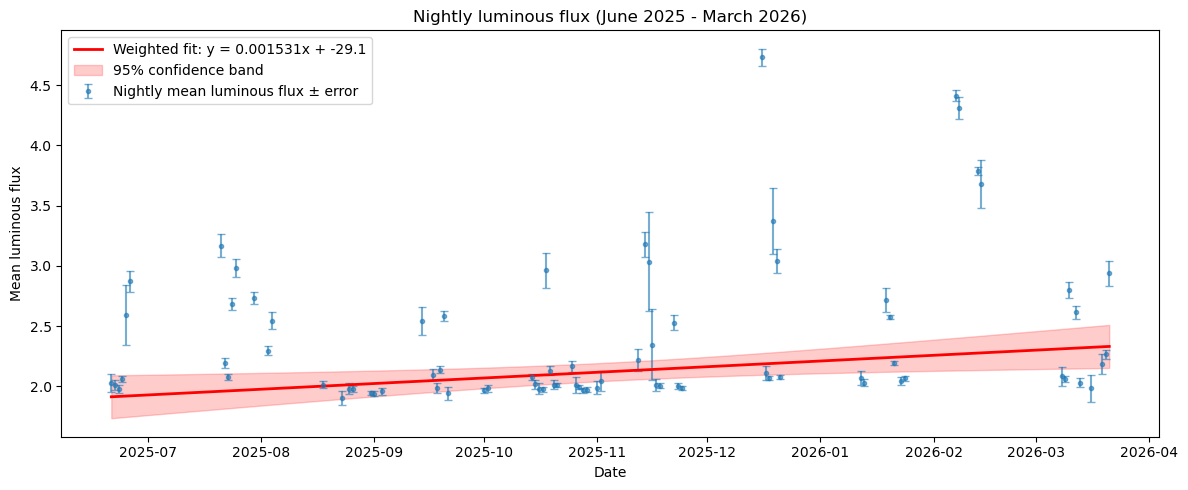

In [13]:
record_set = set([
    str(clear_image_location.joinpath(f"{source_file[:-8]}/AllSkyImage{filename}.JPG"))
    for filename, source_file in enriched_df[["filename", 'source_file']].to_numpy()
])
image_set = set(list([str(x) for x in clear_image_location.glob("20*-*/*.JPG")]))

filtered_df = enriched_df[
    enriched_df['image_paths'].str.replace("Some", "Final").isin(record_set.intersection(image_set))
    & (enriched_df["date"] >= "2025/06/21")
].copy()
filtered_df['image_paths'] = filtered_df['image_paths'].str.replace("Some", "Final")

later_start_df = filtered_df[
    filtered_df['date'] >= "2025/07/21"
]

_ = plot_brightness(later_start_df, "[LATERSTART] July 2025 - March 2026")
_ = plot_brightness(filtered_df, "June 2025 - March 2026", period="D")
_ = plot_exposure(filtered_df, "June 2025 - March 2026", period="D")
_ = plot_synthetic_luminous_flux(filtered_df, "June 2025 - March 2026", period="D")
